In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler,LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report,roc_auc_score,roc_curve
from sklearn.decomposition import PCA

In [102]:
df=pd.read_csv('mushroom.csv')
df.head()

,Unnamed: 0,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class,stalk_height,cap_diameter
0,1167,sunken,scaly,white,no,anise,descending,distant,broad,pink,...,partial,brown,two,sheathing,chocolate,clustered,waste,poisonous,14.276173,5.054983
1,1037,sunken,fibrous,red,no,anise,notched,crowded,narrow,chocolate,...,universal,brown,two,sheathing,brown,numerous,waste,edible,3.952715,19.068319
2,309,flat,grooves,purple,yes,foul,descending,crowded,broad,purple,...,universal,yellow,two,sheathing,purple,abundant,waste,poisonous,9.054265,7.205884
3,282,bell,scaly,pink,yes,fishy,notched,close,broad,orange,...,partial,yellow,two,cobwebby,green,clustered,grasses,poisonous,5.226499,20.932692
4,820,flat,smooth,yellow,yes,musty,free,crowded,narrow,orange,...,universal,white,none,none,yellow,clustered,urban,poisonous,14.037532,12.545245


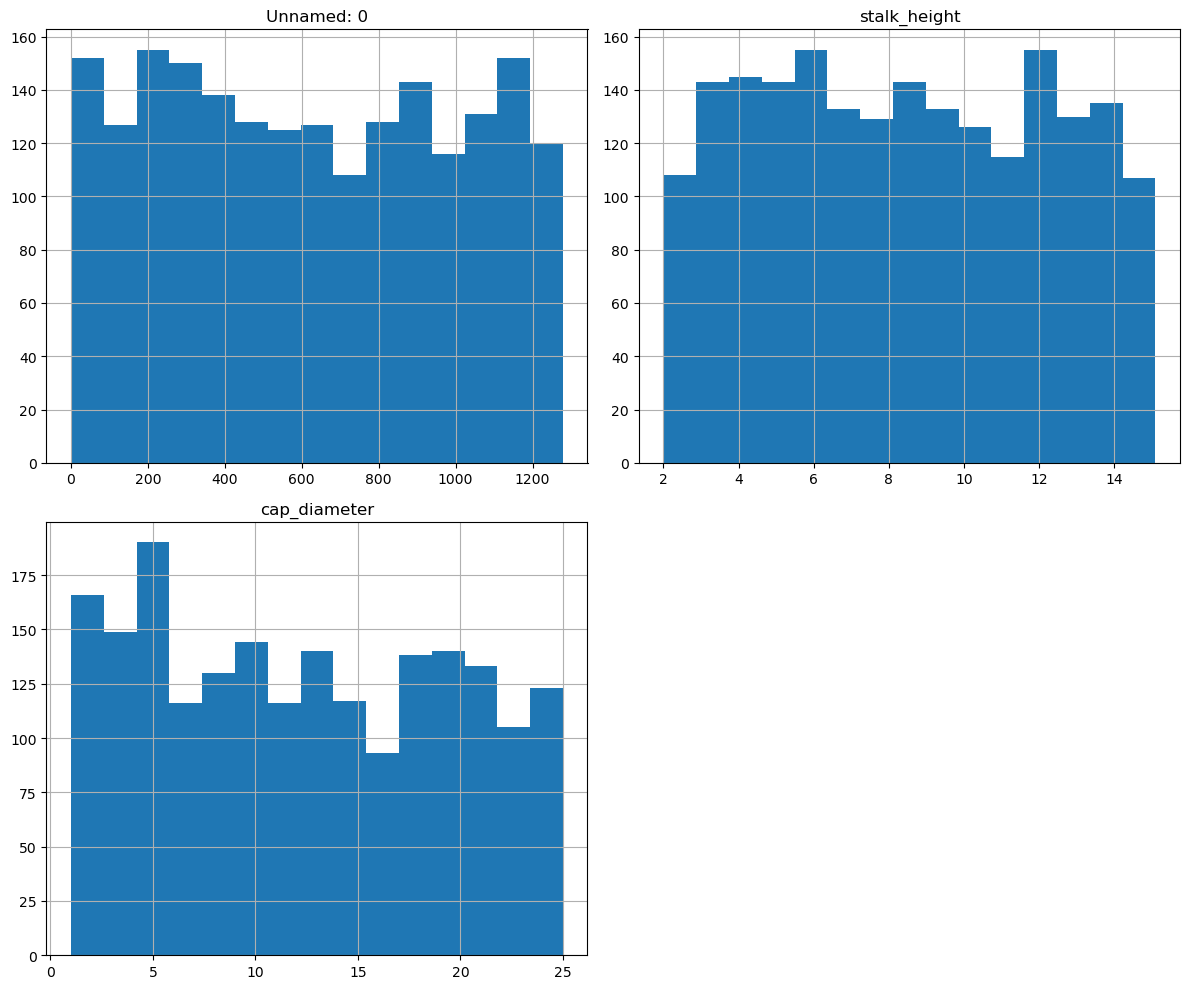

In [103]:
# Histograms of numeric features
df.hist(figsize=(12, 10), bins=15)
plt.tight_layout()
plt.show()

In [104]:
df.shape

(2000, 26)

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                2000 non-null   int64  
 1   cap_shape                 2000 non-null   object 
 2   cap_surface               2000 non-null   object 
 3   cap_color                 2000 non-null   object 
 4   bruises                   2000 non-null   object 
 5   odor                      2000 non-null   object 
 6   gill_attachment           2000 non-null   object 
 7   gill_spacing              2000 non-null   object 
 8   gill_size                 2000 non-null   object 
 9   gill_color                2000 non-null   object 
 10  stalk_shape               2000 non-null   object 
 11  stalk_root                2000 non-null   object 
 12  stalk_surface_above_ring  2000 non-null   object 
 13  stalk_surface_below_ring  2000 non-null   object 
 14  stalk_co

<Axes: xlabel='class', ylabel='count'>

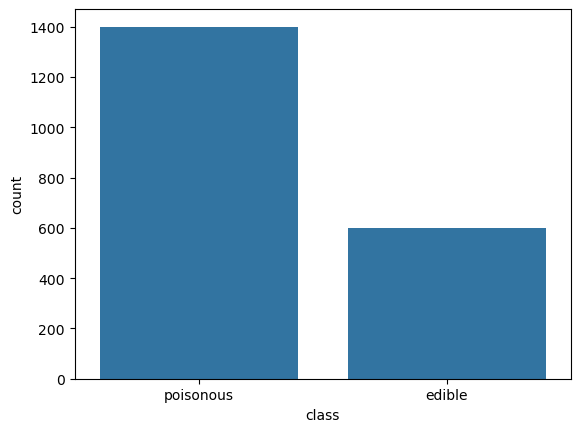

In [106]:
sns.countplot(x='class', data=df)


In [107]:
df.columns

Index(['Unnamed: 0', 'cap_shape', 'cap_surface', 'cap_color', 'bruises',
       'odor', 'gill_attachment', 'gill_spacing', 'gill_size', 'gill_color',
       'stalk_shape', 'stalk_root', 'stalk_surface_above_ring',
       'stalk_surface_below_ring', 'stalk_color_above_ring',
       'stalk_color_below_ring', 'veil_type', 'veil_color', 'ring_number',
       'ring_type', 'spore_print_color', 'population', 'habitat', 'class',
       'stalk_height', 'cap_diameter'],
      dtype='object')

In [108]:
cols=['Unnamed: 0', 'cap_shape', 'cap_surface', 'cap_color', 'bruises',
       'odor', 'gill_attachment', 'gill_spacing', 'gill_size', 'gill_color',
       'stalk_shape', 'stalk_root', 'stalk_surface_above_ring',
       'stalk_surface_below_ring', 'stalk_color_above_ring',
       'stalk_color_below_ring', 'veil_type', 'veil_color', 'ring_number',
       'ring_type', 'spore_print_color', 'population', 'habitat', 'class',
       'stalk_height', 'cap_diameter']

In [109]:
df.columns=cols

C:\Users\hp\AppData\Local\Temp\ipykernel_34092\2969992854.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set2')


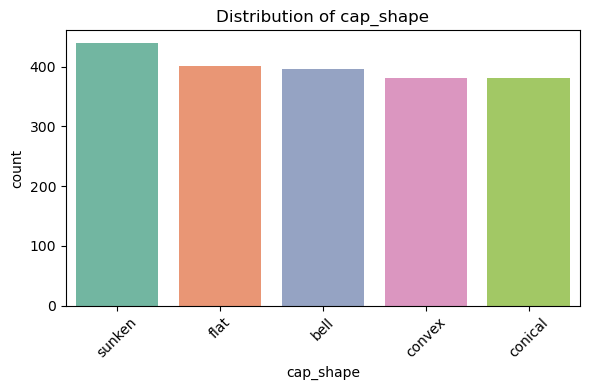

C:\Users\hp\AppData\Local\Temp\ipykernel_34092\2969992854.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set2')


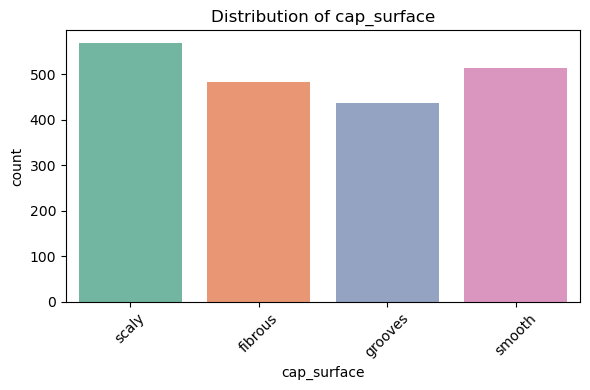

C:\Users\hp\AppData\Local\Temp\ipykernel_34092\2969992854.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set2')


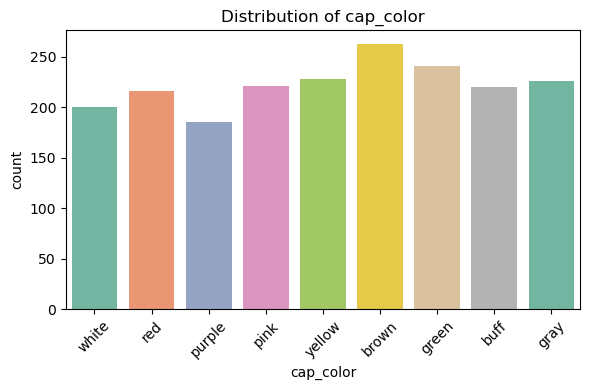

C:\Users\hp\AppData\Local\Temp\ipykernel_34092\2969992854.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set2')


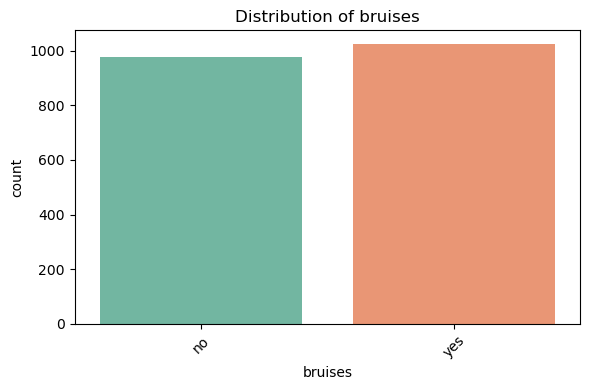

C:\Users\hp\AppData\Local\Temp\ipykernel_34092\2969992854.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set2')


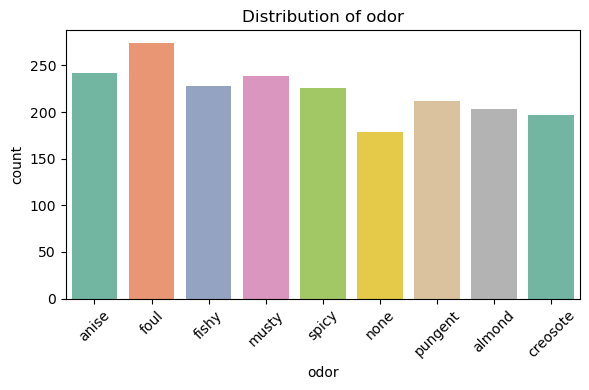

C:\Users\hp\AppData\Local\Temp\ipykernel_34092\2969992854.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set2')


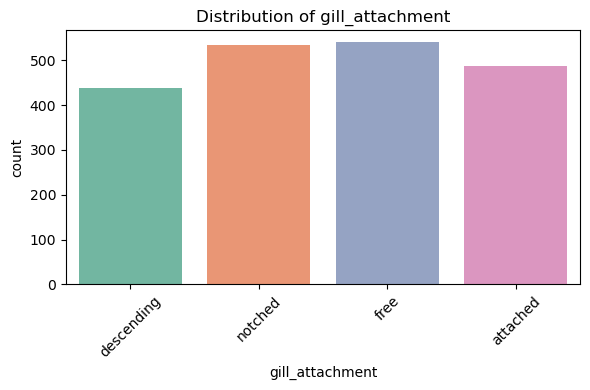

C:\Users\hp\AppData\Local\Temp\ipykernel_34092\2969992854.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set2')


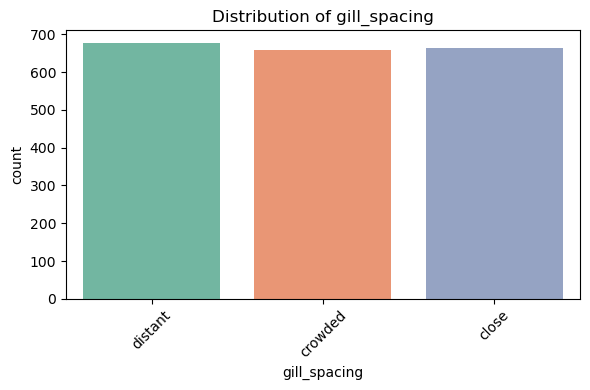

C:\Users\hp\AppData\Local\Temp\ipykernel_34092\2969992854.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set2')


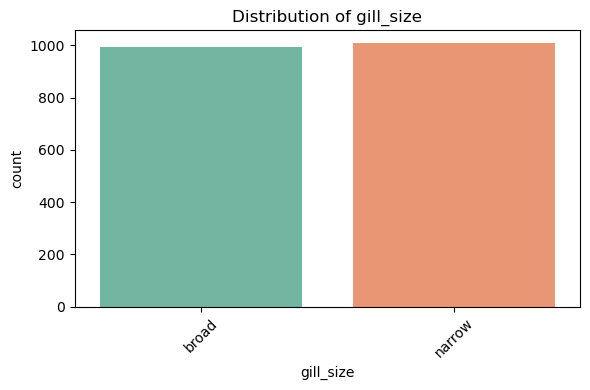

C:\Users\hp\AppData\Local\Temp\ipykernel_34092\2969992854.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set2')


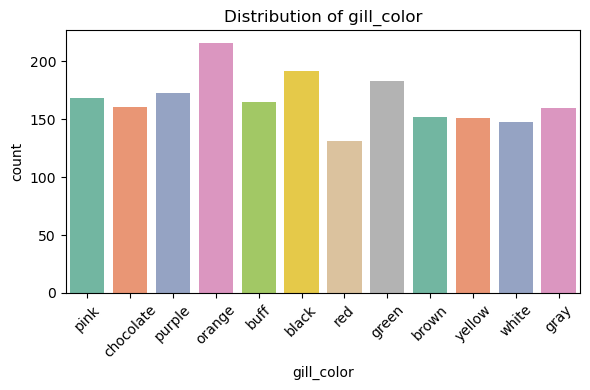

C:\Users\hp\AppData\Local\Temp\ipykernel_34092\2969992854.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set2')


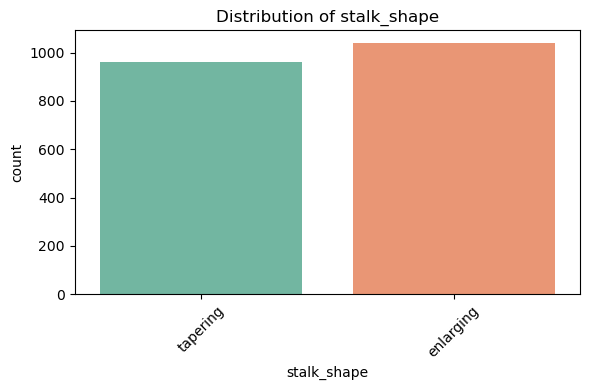

C:\Users\hp\AppData\Local\Temp\ipykernel_34092\2969992854.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set2')


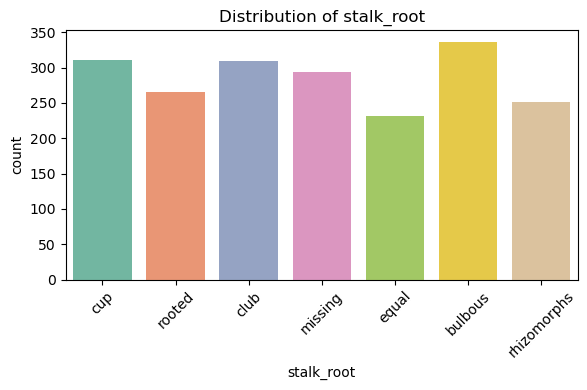

C:\Users\hp\AppData\Local\Temp\ipykernel_34092\2969992854.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set2')


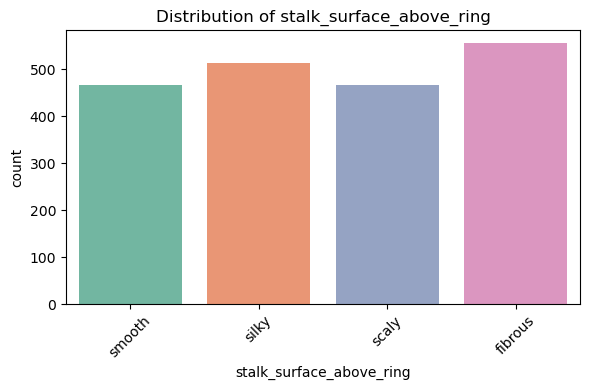

C:\Users\hp\AppData\Local\Temp\ipykernel_34092\2969992854.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set2')


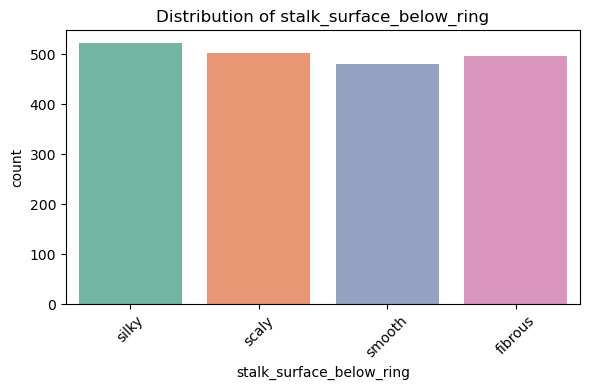

C:\Users\hp\AppData\Local\Temp\ipykernel_34092\2969992854.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set2')


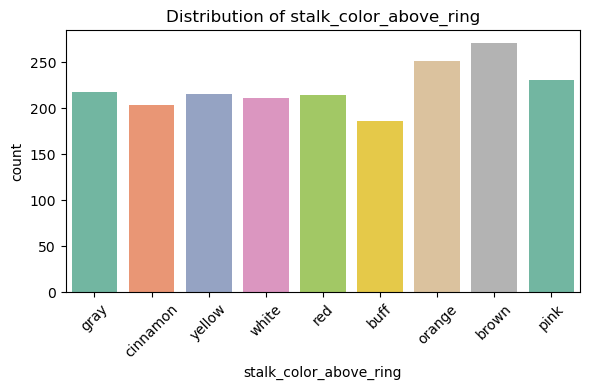

C:\Users\hp\AppData\Local\Temp\ipykernel_34092\2969992854.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set2')


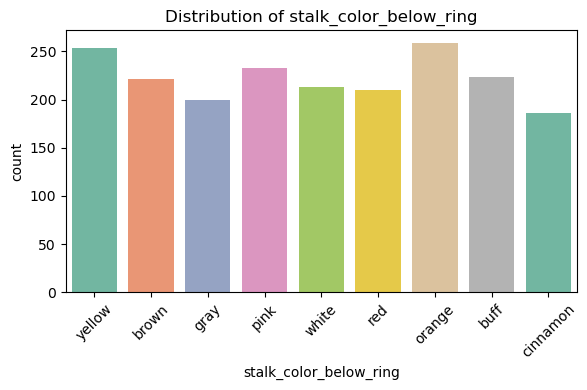

C:\Users\hp\AppData\Local\Temp\ipykernel_34092\2969992854.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set2')


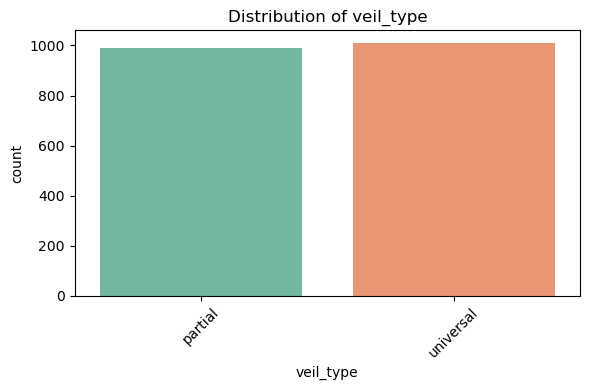

C:\Users\hp\AppData\Local\Temp\ipykernel_34092\2969992854.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set2')


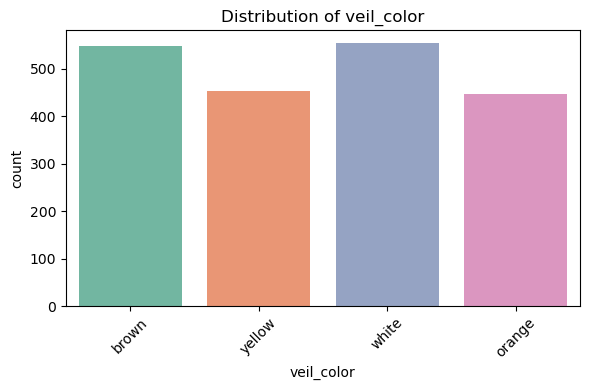

C:\Users\hp\AppData\Local\Temp\ipykernel_34092\2969992854.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set2')


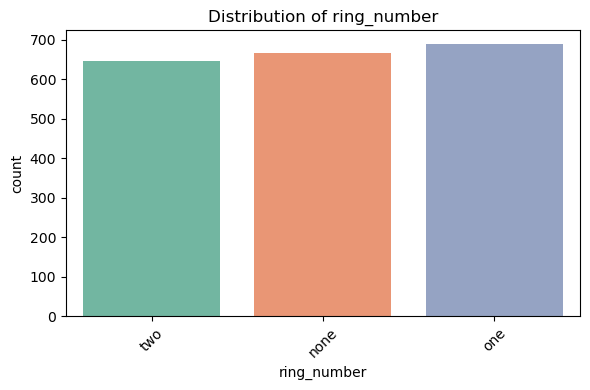

C:\Users\hp\AppData\Local\Temp\ipykernel_34092\2969992854.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set2')


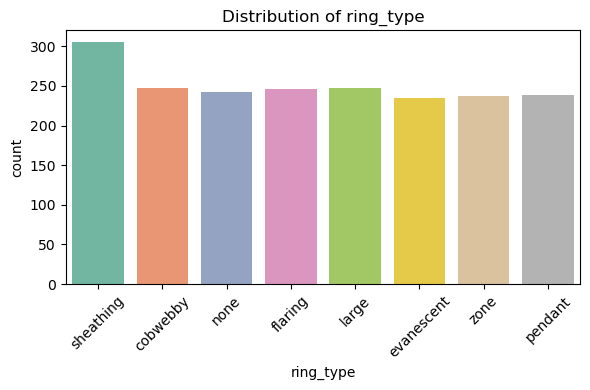

C:\Users\hp\AppData\Local\Temp\ipykernel_34092\2969992854.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set2')


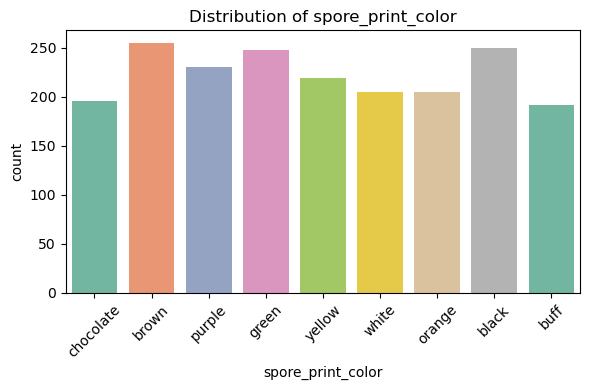

C:\Users\hp\AppData\Local\Temp\ipykernel_34092\2969992854.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set2')


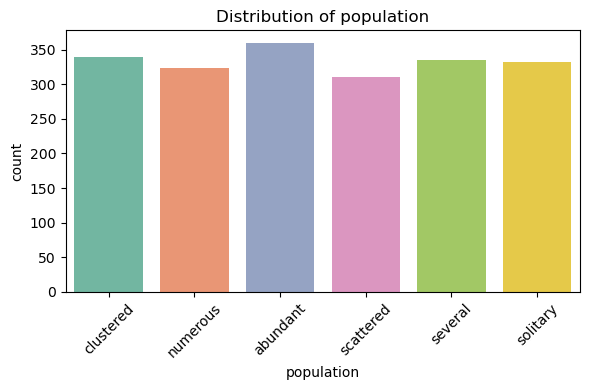

C:\Users\hp\AppData\Local\Temp\ipykernel_34092\2969992854.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set2')


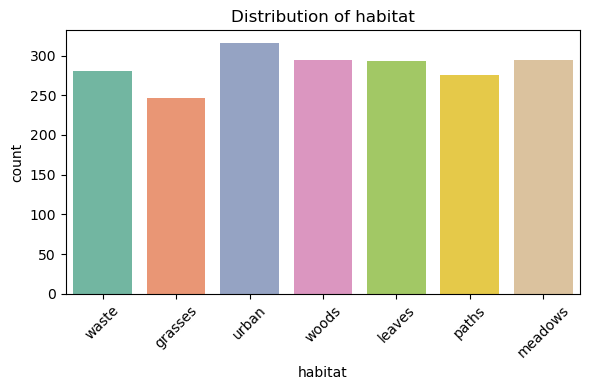

C:\Users\hp\AppData\Local\Temp\ipykernel_34092\2969992854.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set2')


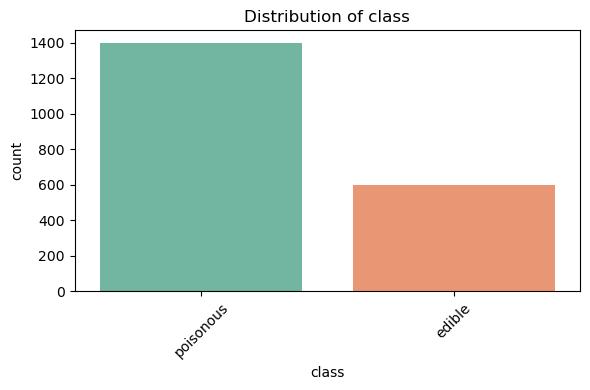

In [110]:
categorical_col = df.select_dtypes(include=['object']).columns

# Plot each categorical column
for col in categorical_col:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df, palette='Set2')
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [111]:
df.isna().sum()

Unnamed: 0                  0
cap_shape                   0
cap_surface                 0
cap_color                   0
bruises                     0
odor                        0
gill_attachment             0
gill_spacing                0
gill_size                   0
gill_color                  0
stalk_shape                 0
stalk_root                  0
stalk_surface_above_ring    0
stalk_surface_below_ring    0
stalk_color_above_ring      0
stalk_color_below_ring      0
veil_type                   0
veil_color                  0
ring_number                 0
ring_type                   0
spore_print_color           0
population                  0
habitat                     0
class                       0
stalk_height                0
cap_diameter                0
dtype: int64

In [112]:
df.duplicated().sum()

np.int64(1024)

In [113]:
df.drop_duplicates(inplace=True,ignore_index=True)

In [114]:
df.duplicated().sum()

np.int64(0)

In [115]:
df.shape

(976, 26)

In [116]:
X = df.drop('class', axis=1)
y = df['class']

In [117]:
numeric_cols = X.select_dtypes(exclude=['object']).columns
categorical_cols= X.select_dtypes(include=['object']).columns

In [118]:
encoder = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ],
    remainder='passthrough'  # keep other columns as-is if any
)

In [119]:
X_encoded = encoder.fit_transform(X)

In [120]:
le = LabelEncoder()

y_encoded = le.fit_transform(y)

In [121]:
x_train,x_test,y_train,y_test=train_test_split(X_encoded,y_encoded,test_size=0.2)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((780, 105), (196, 105), (780,), (196,))

In [122]:
model=SVC(C=0.6,kernel='linear')
model.fit(x_train,y_train)

SVC(C=0.6, kernel='linear')

In [123]:

def evaluate_cif(y, yhat):
    # Confusion Matrix
    cm = confusion_matrix(y, yhat)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y, yhat))

    # ROC Curve and AUC
    plt.figure(figsize=(5, 4))
    plt.title('ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')

    unique_classes = np.unique(y)

    # ---- Binary classification ----
    if len(unique_classes) == 2:
        pos_label = unique_classes[1]  # Automatically detect positive label
        fpr, tpr, _ = roc_curve(y, yhat, pos_label=pos_label)
        auc = roc_auc_score(y, yhat)
        plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
        plt.legend()

    # ---- Multiclass classification ----
    else:
        y_bin = label_binarize(y, classes=unique_classes)
        yhat_bin = label_binarize(yhat, classes=unique_classes)
        auc = roc_auc_score(y_bin, yhat_bin, average='macro')
        for i in range(y_bin.shape[1]):
            fpr, tpr, _ = roc_curve(y_bin[:, i], yhat_bin[:, i])
            plt.plot(fpr, tpr, label=f'Class {unique_classes[i]}')
        plt.legend(title=f'Macro AUC = {auc:.2f}')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.show()


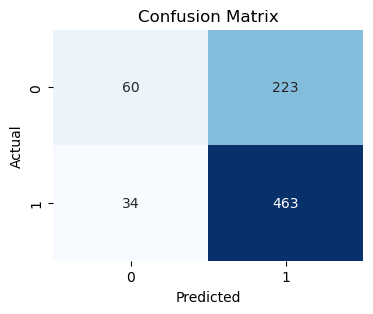


Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.21      0.32       283
           1       0.67      0.93      0.78       497

    accuracy                           0.67       780
   macro avg       0.66      0.57      0.55       780
weighted avg       0.66      0.67      0.61       780



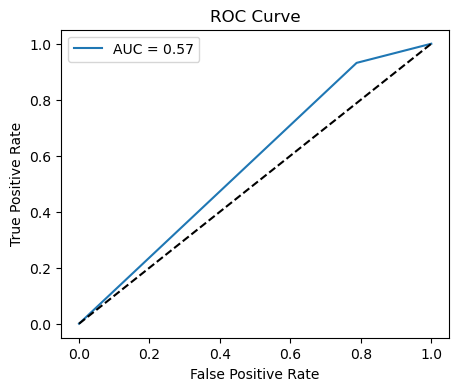

In [124]:
yhat_train=model.predict(x_train)
evaluate_cif(y_train,yhat_train)

In [131]:
for kernel in ['linear', 'poly', 'rbf', 'sigmoid']:
    model = SVC(kernel=kernel, C=1.0, gamma='scale', class_weight='balanced', random_state=42)
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    print(f"Kernel: {kernel}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("-"*60)


Kernel: linear
Accuracy: 0.49489795918367346
Classification Report:
               precision    recall  f1-score   support

           0       0.38      0.53      0.45        75
           1       0.62      0.47      0.54       121

    accuracy                           0.49       196
   macro avg       0.50      0.50      0.49       196
weighted avg       0.53      0.49      0.50       196

------------------------------------------------------------
Kernel: poly
Accuracy: 0.5918367346938775
Classification Report:
               precision    recall  f1-score   support

           0       0.42      0.17      0.25        75
           1       0.62      0.85      0.72       121

    accuracy                           0.59       196
   macro avg       0.52      0.51      0.48       196
weighted avg       0.55      0.59      0.54       196

------------------------------------------------------------
Kernel: rbf
Accuracy: 0.5357142857142857
Classification Report:
               precision 

In [134]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1,0.6, 1, 10],
    'gamma': ['scale', 'auto', 0.1, 0.01],
    'kernel': ['linear', 'rbf', 'poly']
}

grid = GridSearchCV(SVC(class_weight='balanced', random_state=42), param_grid, cv=5, scoring='f1_weighted')
grid.fit(x_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)


Best Parameters: {'C': 0.6, 'gamma': 0.1, 'kernel': 'poly'}
Best Score: 0.5491727772117962


In [136]:
best_svm = SVC(kernel='poly', C=0.6, gamma=0.1, class_weight='balanced', random_state=42)
best_svm.fit(x_train, y_train)

SVC(C=0.6, class_weight='balanced', gamma=0.1, kernel='poly', random_state=42)

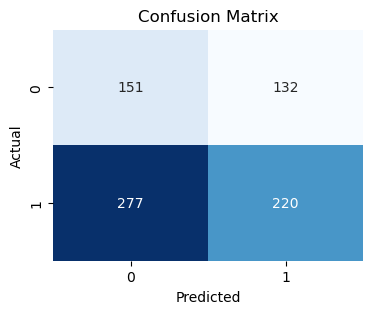


Classification Report:
              precision    recall  f1-score   support

           0       0.35      0.53      0.42       283
           1       0.62      0.44      0.52       497

    accuracy                           0.48       780
   macro avg       0.49      0.49      0.47       780
weighted avg       0.53      0.48      0.48       780



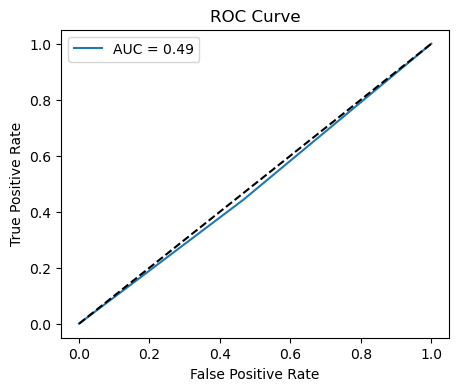

In [137]:
yhat_train=model.predict(x_train)
evaluate_cif(y_train,yhat_train)

#### Analysis of SVM on Mushroom Dataset:
###### The SVM performed reasonably well in classifying mushrooms, especially after encoding categorical variables. It effectively handled the high-dimensional data created by one-hot encoding and captured nonlinear relationships using kernels like RBF and polynomial. However, it showed bias toward the majority class, indicating sensitivity to class imbalance. SVM also requires careful tuning of parameters such as C and gamma for optimal performance and can be computationally expensive on large datasets.

#### Practical Implications of SVM in Real-World Tasks:
###### SVM is widely used in areas like medical diagnosis, text classification, and image recognition due to its high accuracy and ability to separate complex data patterns. It performs well in tasks where precision is critical and data is not linearly separable. However, in real-world applications with large datasets or many classes, SVMs may become slow and harder to interpret compared to simpler models like logistic regression or faster ones like Random Forest and XGBoost.